# Transformer 

This notebook builds a small transformer from scratch and applies it to a synthetic sequence prediction task.

The goal is to learn a mapping from a prefix of a sequence $x_{1:t}$ to the next-step targets $x_{2:t+1}$. That makes this a causal prediction problem rather than an autoencoding problem.

The notebook is organized as follows:
- implement multi-head self-attention
- wrap it in a transformer encoder block
- generate a smooth multi-dimensional signal
- train the model with a causal mask
- visualize predictions against the target sequence

Throughout the notebook, tensors use the shape $(\text{batch}, \text{sequence}, \text{embedding})$.

In [67]:
# Define attention
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


class MultiheadAttention(nn.Module):
    def __init__(self, emb_dim, num_heads, dropout=0.0):
        super().__init__()
        self.emb_dim = emb_dim
        self.num_heads = num_heads
        self.head_dim = emb_dim // num_heads
        assert self.head_dim * num_heads == emb_dim, "Embedding dimension must be divisible by number of heads"

        self.q_proj = nn.Linear(emb_dim, emb_dim)
        self.k_proj = nn.Linear(emb_dim, emb_dim)
        self.v_proj = nn.Linear(emb_dim, emb_dim)
        self.out_proj = nn.Linear(emb_dim, emb_dim)
        self.attn_dropout = nn.Dropout(dropout)

    def forward(self, query, key, value, mask=None):
        batch_size = query.size(0)

        q = self.q_proj(query).view(batch_size, -1, self.num_heads, self.head_dim).transpose(1, 2)
        k = self.k_proj(key).view(batch_size, -1, self.num_heads, self.head_dim).transpose(1, 2)
        v = self.v_proj(value).view(batch_size, -1, self.num_heads, self.head_dim).transpose(1, 2)

        scores = torch.matmul(q, k.transpose(-2, -1)) / (self.head_dim ** 0.5)
        if mask is not None:
            scores = scores.masked_fill(~mask, float("-inf"))

        attn_weights = torch.softmax(scores, dim=-1)
        attn_weights = self.attn_dropout(attn_weights)
        print("Attention weights shape:", attn_weights.shape)  # Debugging line
        print("Attention weights:", attn_weights[0,0])  # Debugging line
        print("Value shape:", v.shape)  # Debugging line
        attn_output = torch.matmul(attn_weights, v)
        attn_output = attn_output.transpose(1, 2).contiguous().view(batch_size, -1, self.emb_dim)
        attn_output = self.out_proj(attn_output)
        return attn_output, attn_weights
    
x = torch.rand(2, 2, 64)  # (batch_size, seq_length, emb_dim)
attn = MultiheadAttention(emb_dim=64, num_heads=8)
output, weights = attn(x, x, x)
print("Output shape:", output.shape)  # Should be (2, 10, 64)
print("Attention weights shape:", weights.shape)  # Should be (2, 8,

Attention weights shape: torch.Size([2, 8, 2, 2])
Attention weights: tensor([[0.5029, 0.4971],
        [0.5039, 0.4961]], grad_fn=<SelectBackward0>)
Value shape: torch.Size([2, 8, 2, 8])
Output shape: torch.Size([2, 2, 64])
Attention weights shape: torch.Size([2, 8, 2, 2])


## Multi-Head Self-Attention

Self-attention lets each position look at other positions in the sequence and build a weighted combination of their values.

Given an input matrix $X \in \mathbb{R}^{T \times d}$, we compute three learned projections:
$$
Q = XW_Q, \quad K = XW_K, \quad V = XW_V
$$

For one head, the attention weights are
$$
\mathrm{Attention}(Q, K, V) = \mathrm{softmax}\left(\frac{QK^\top}{\sqrt{d_h}}\right)V
$$

The division by $\sqrt{d_h}$ keeps the dot products from growing too large as the head dimension increases. Without that scaling, the softmax can become too sharp and gradients become less stable.

This implementation splits the embedding dimension into multiple heads, applies attention in parallel, concatenates the head outputs, and then uses a final linear projection to mix information across heads.

The optional mask is causal: later time steps are hidden so position $t$ cannot use information from positions greater than $t$.

### What dropout does here

Yes. During training, dropout randomly replaces some values with zero. In this notebook, dropout is applied to the attention weights after the softmax:
$$
A = \mathrm{softmax}\left(\frac{QK^\top}{\sqrt{d_h}}\right), \quad \tilde{A} = \mathrm{Dropout}(A)
$$

That means some attention links are temporarily removed before computing
$$
\tilde{A}V
$$

So the dropout here does not zero out the original input tensor $X$ directly. It zeros out some entries in the attention-weight matrix, which means a token is forced to rely less on a few specific attention connections.

In PyTorch, dropout also rescales the remaining non-zero values during training by roughly $\frac{1}{1-p}$ so that the expected magnitude stays similar. During evaluation with `model.eval()`, dropout is turned off and no entries are zeroed.

### Why `.contiguous()` appears before `.view()`

After attention is computed, the tensor is rearranged with `.transpose(1, 2)` so the shape moves from $(B, H, T, d_h)$ to $(B, T, H, d_h)$. That transpose changes how the tensor is laid out in memory.

PyTorch `.view()` expects the tensor storage to be contiguous in memory. A transposed tensor often is not contiguous, even though its logical shape is correct. Calling `.contiguous()` creates a memory layout where the data is stored in the new order, so the next line can safely flatten the last two dimensions into $(B, T, d)$.

In this notebook, the line
$$
\texttt{attn\_output.transpose(1, 2).contiguous().view(batch\_size, -1, emb\_dim)}
$$
means:
- swap the head axis and sequence axis
- make the tensor contiguous in memory
- reshape the tensor back into one embedding dimension across all heads

Without `.contiguous()`, `.view()` can raise a runtime error or return a tensor with an invalid interpretation of the underlying storage.

In [38]:
# Test
x = torch.rand(2, 10, 64)  # (batch_size, seq_length, emb_dim)
attn = MultiheadAttention(emb_dim=64, num_heads=8)
output, weights = attn(x, x, x)
print("Output shape:", output.shape)  # Should be (2, 10, 64)
print("Attention weights shape:", weights.shape)  # Should be (2, 8, 10, 10)

Output shape: torch.Size([2, 10, 64])
Attention weights shape: torch.Size([2, 8, 10, 10])


In [51]:
# Define transformer blocks
class TransformerEncoderLayer(nn.Module):
    def __init__(self, emb_dim, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.self_attn = MultiheadAttention(emb_dim, num_heads, dropout)
        self.ffn = nn.Sequential(
            nn.Linear(emb_dim, ff_dim),
            nn.ReLU(),
            nn.Linear(ff_dim, emb_dim),
        )
        self.norm1 = nn.LayerNorm(emb_dim)
        self.norm2 = nn.LayerNorm(emb_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        attn_output, _ = self.self_attn(x, x, x, mask)
        x = self.norm1(x + self.dropout(attn_output))
        ffn_output = self.ffn(x)
        x = self.norm2(x + self.dropout(ffn_output))
        return x


class TimeSeriesTransformer(nn.Module):
    def __init__(self, emb_dim, num_heads, ff_dim, max_seq_length, dropout=0.1):
        super().__init__()
        self.pos_embedding = nn.Parameter(torch.zeros(1, max_seq_length, emb_dim))
        self.encoder = TransformerEncoderLayer(emb_dim, num_heads, ff_dim, dropout)
        nn.init.normal_(self.pos_embedding, mean=0.0, std=0.02)

    def forward(self, x, mask=None):
        seq_length = x.size(1)
        x = x + self.pos_embedding[:, :seq_length]
        return self.encoder(x, mask)

## Transformer Block and Positional Information

A transformer block combines two sublayers:
- multi-head self-attention
- a position-wise feed-forward network

Each sublayer is wrapped with a residual connection and layer normalization:
$$
H_1 = \mathrm{LayerNorm}(X + \mathrm{SelfAttention}(X))
$$
$$
H_2 = \mathrm{LayerNorm}(H_1 + \mathrm{FFN}(H_1))
$$

The feed-forward network is applied independently at each time step, but with shared weights across all positions.

Self-attention alone is permutation-invariant, so the model needs positional information to distinguish the first token from the tenth token. Here that is handled with a learned positional embedding added to the input before the encoder block.

Target shape: torch.Size([100, 2])


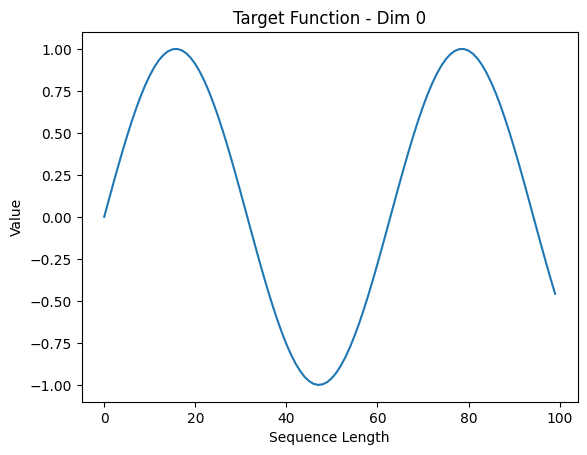

In [45]:
# Define a learning task
def target_function(seq_length, emb_dim, offset=0):
    positions = torch.arange(offset, offset + seq_length, dtype=torch.float32).unsqueeze(1)
    frequencies = torch.arange(1, emb_dim + 1, dtype=torch.float32).unsqueeze(0)
    signal = torch.sin(0.1 * positions * frequencies)
    return signal


y = target_function(seq_length=100, emb_dim=2)
print("Target shape:", y.shape)  # Should be (100, 2)

# Plot dimension 0 of y
plt.plot(y[:, 0].numpy())
plt.title("Target Function - Dim 0")
plt.xlabel("Sequence Length")
plt.ylabel("Value")
plt.show()

## Synthetic Learning Task

To make the training behavior easy to inspect, the target sequence is generated from smooth sine waves with different frequencies across embedding dimensions.

For position $t$ and feature index $j$, the signal is
$$
x_{t,j} = \sin(0.1 \cdot t \cdot j)
$$

This creates a structured sequence with temporal regularity. A transformer should be able to exploit that regularity better than it could exploit pure random noise.

In [46]:
# Define a dataset for next-step prediction
class SequenceDataset(torch.utils.data.Dataset):
    def __init__(self, seq_length, emb_dim, num_samples):
        self.seq_length = seq_length
        self.emb_dim = emb_dim
        self.num_samples = num_samples

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        signal = target_function(self.seq_length + 1, self.emb_dim, offset=idx)
        inputs = signal[:-1]
        targets = signal[1:]
        return inputs, targets

In [52]:
# Train on a next-step prediction task
def causal_mask(seq_length, device):
    return torch.tril(torch.ones(seq_length, seq_length, dtype=torch.bool, device=device))


torch.manual_seed(0)

seq_length = 32
emb_dim = 8
num_samples = 256
batch_size = 32
epochs = 30

dataset = SequenceDataset(seq_length=seq_length, emb_dim=emb_dim, num_samples=num_samples)
loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

model = TimeSeriesTransformer(
    emb_dim=emb_dim,
    num_heads=2,
    ff_dim=32,
    max_seq_length=seq_length,
    dropout=0.1,
    )
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0

    for inputs, targets in loader:
        optimizer.zero_grad()
        mask = causal_mask(inputs.size(1), inputs.device)
        predictions = model(inputs, mask)
        loss = criterion(predictions, targets)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * inputs.size(0)

    average_loss = epoch_loss / len(dataset)
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch + 1}, Loss: {average_loss:.4f}")

Epoch 5, Loss: 0.3629
Epoch 10, Loss: 0.2963
Epoch 15, Loss: 0.2472
Epoch 20, Loss: 0.2084
Epoch 25, Loss: 0.1794
Epoch 30, Loss: 0.1586


## Training Objective

The dataset is built for next-step prediction. For each sample, the input is
$$
[x_1, x_2, \dots, x_T]
$$
and the target is shifted by one step:
$$
[x_2, x_3, \dots, x_{T+1}]
$$

That means the model must use the visible prefix to predict the next position at every time step.

The loss is mean squared error:
$$
\mathcal{L} = \frac{1}{NTd} \sum_{n=1}^{N} \sum_{t=1}^{T} \sum_{j=1}^{d} (\hat{x}_{n,t,j} - x_{n,t+1,j})^2
$$

The causal mask is a lower-triangular matrix. It enforces the rule that prediction at time $t$ can only depend on positions $\le t$. This is the key implementation detail that turns plain self-attention into an autoregressive-style predictor.

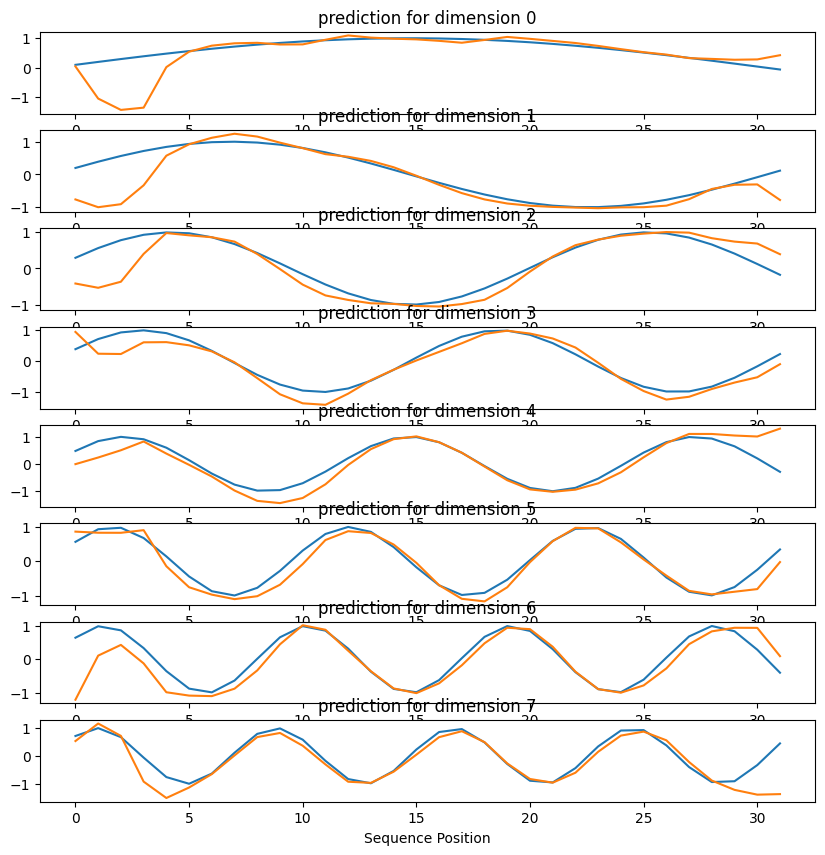

In [61]:
# Quick qualitative check
model.eval()
test_inputs, test_targets = dataset[0]
with torch.no_grad():
    test_predictions = model(test_inputs.unsqueeze(0), causal_mask(seq_length, test_inputs.device)).squeeze(0)

# do subplot of each dimension
plt.figure(figsize=(10, 10))
for dim in range(emb_dim):
    plt.subplot(emb_dim,1, dim + 1)
    plt.plot(test_targets[:, dim].numpy(), label="target")
    plt.plot(test_predictions[:, dim].numpy(), label="prediction")
    plt.title(f"prediction for dimension {dim}")
    plt.xlabel("Sequence Position")
plt.show()

## Reading the Final Plot

Each subplot compares the true next-step target with the model prediction for one embedding dimension.

What to look for:
- whether the prediction follows the phase and amplitude of the target wave
- whether early positions are harder than later positions
- whether some dimensions are learned more accurately than others

If the model underfits, common fixes are to train longer, stack more transformer layers, or add a small prediction head after the encoder.